# Exercise 5 – Hypothesis Testing
**Course:** Analysis and Visualisation of Complex Agro-Environmental Data  
**Student:** [Your Name]

This notebook solves Exercise 5 using the EFIplus Mediterranean dataset.

Main analyses:
1. Comparison of Mean Annual Temperature between Brown Trout presence and absence sites
2. Test of independence between Brown Trout presence/absence and country
3. ANOVA for upstream catchment elevation among the 8 most sampled catchments
4. Non-parametric equivalent of ANOVA and comparison

In [1]:
%pip install plotly statsmodels scikit-posthocs

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 8.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.9 MB 11.5 MB/s eta 0:00:01
   ----------------------------------- ---- 8.9/9.9 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 16.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.6 MB 15.0 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 20.5 MB/s  0:00:00

   ---------------------------------------- 0/5 [patsy]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   ---------------- -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import zipfile
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import scikit_posthocs as sp

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
zip_path = "EFIplus_medit.zip"
extract_folder = "efi_data"

if not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

csv_path = os.path.join(extract_folder, "EFIplus_medit.csv")

df = pd.read_csv(csv_path, sep=";")
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,Geomorph2,Geomorph3,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Barriers_catchment_down,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,Impoundment,Hydropeaking,Water_abstraction,Hydro_mod,Temperature_impact,Velocity_increase,Reservoir_flushing,Sedimentation,Channelisation,Cross_sec,Instream_habitat,Riparian_vegetation,Embankment,Floodprotection,Floodplain,Toxic_substances,Acidification,Water_quality_index,Eutrophication,Organic_pollution,Organic_siltation,Sum of Run1_number_all,Total_sp,Abramis brama,Achondrostoma arcasii,Achondrostoma occidentale,Achondrostoma oligolepis,Acipenser naccarii,Alburnoides bipunctatus,Alburnus albidus,Alburnus alburnus,Alosa alosa,Alosa fallax,Ameiurus melas,Anaecypris hispanica,Anguilla anguilla,Atherina boyeri,Australoheros facetus,Barbatula barbatula,Barbatula quignardi,Barbus barbus,Barbus bocagei,Barbus comizo,Barbus graellsii,Barbus haasi,Barbus meridionalis,Barbus microcephalus,Barbus plebejus,Barbus sclateri,Barbus tyberinus,Blicca bjoerkna,Carassius auratus,Carassius carassius,Chelon labrosus,Chondrostoma genei,Chondrostoma nasus,Chondrostoma soetta,Chondrostoma toxostoma,Cobitis calderoni,Cobitis paludica,Cobitis taenia,Cottus gobio,Cottus hispaniolensis,Cyprinus carpio,Dicentrarchus labrax,Esox lucius,Gambusia affinis,Gambusia holbrooki,Gasterosteus aculeatus,Gasterosteus gymnurus,Gobio gobio,Gobio lozanoi,Gymnocephalus cernuus,Hypophthalmichthys molitrix,Iberochondrostoma almacai,Iberochondrostoma lemmingii,Iberochondrostoma lusitanicum,Lampetra fluviatilis,Lampetra planeri,Lepomis gibbosus,Leuciscus cephalus,Leuciscus leuciscus,Leuciscus lucumonis,Leuciscus souffia,Liza aurata,Liza ramada,Luciobarbus guiraonis,Micropterus salmoides,Mugil cephalus,Oncorhynchus mykiss,Pachychilon pictum,Padogobius martensii,Padogobius nigricans,Parachondrostoma arrigonis,Parachondrostoma miegii,Parachondrostoma turiense,Perca fluviatilis,Petromyzon marinus,Phoxinus bigerri,Phoxinus phoxinus,Platichthys flesus,Pseudochondrostoma duriense,Pseudochondrostoma polylepis,Pseudochondrostoma willkommii,Pseudorasbora parva,Rhodeus amarus,Rutilus aula,Rutilus rubilio,Rutilus rutilus,Salaria fluviatilis,Salmo salar,Salmo trutta fario,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius alburnoides,Squalius aradensis,Squalius carolitertii,Squalius laietanus,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,1,1,-0.047266,-1.039638,0.451016,Pluvial,Permanent,199,Siliceous,0.001,3.0,700.840807,522.071164,17.6,8.5,28.1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,1.0,1.0,1.0,1,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,1,1,0.389648,-0.443332,0.489422,Groundwater,Permanent,1253,Calcareous,13.406,3.0,1603.519424,640.327779,9.3,0.6,18.9,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1

In [4]:
print(df.shape)
print(df.columns.tolist())

(5011, 164)
['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication'

In [5]:
# Keep only relevant columns
cols = [
    "Country",
    "Catchment_name",
    "Elevation_mean_catch",
    "temp_ann",
    "Salmo trutta fario"
]

data = df[cols].copy()

# Rename fish column to something easier to type
data = data.rename(columns={"Salmo trutta fario": "brown_trout"})

# Convert to numeric where needed
data["temp_ann"] = pd.to_numeric(data["temp_ann"], errors="coerce")
data["Elevation_mean_catch"] = pd.to_numeric(data["Elevation_mean_catch"], errors="coerce")
data["brown_trout"] = pd.to_numeric(data["brown_trout"], errors="coerce")

# Drop missing values only where needed later
data.head()

,Country,Catchment_name,Elevation_mean_catch,temp_ann,brown_trout
0,Spain,Guadalquivir,700.840807,17.6,0
1,Spain,Tejo,1603.519424,9.3,1
2,Spain,Tejo,1578.678579,10.1,1
3,Spain,Tejo,1553.219128,10.1,1
4,Spain,Tejo,1539.684999,10.3,1


In [6]:
data["trout_presence"] = data["brown_trout"].map({1: "Presence", 0: "Absence"})
data["trout_presence"].value_counts(dropna=False)

trout_presence
Presence    3035
Absence     1976
Name: count, dtype: int64

PART D — Exercise 5, Question 1

In [7]:
q1 = data[["temp_ann", "trout_presence"]].dropna().copy()

presence = q1[q1["trout_presence"] == "Presence"]["temp_ann"]
absence  = q1[q1["trout_presence"] == "Absence"]["temp_ann"]

print("Presence n =", len(presence))
print("Absence n  =", len(absence))

Presence n = 2941
Absence n  = 1900


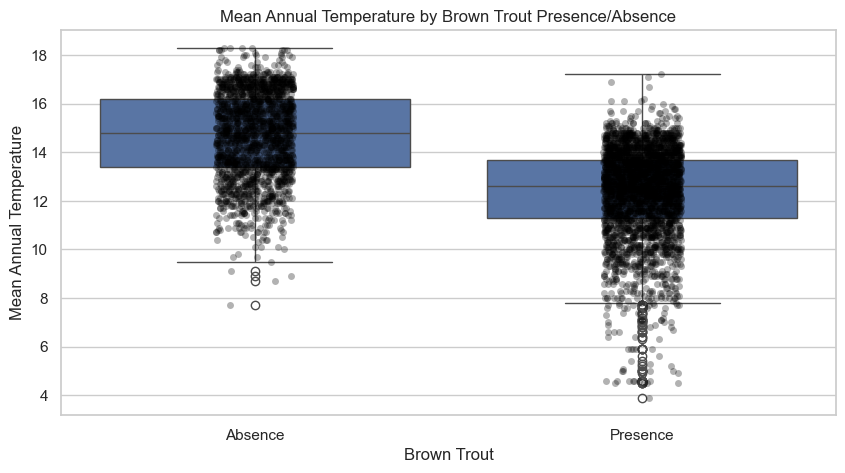

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=q1, x="trout_presence", y="temp_ann")
sns.stripplot(data=q1, x="trout_presence", y="temp_ann", color="black", alpha=0.3)
plt.title("Mean Annual Temperature by Brown Trout Presence/Absence")
plt.xlabel("Brown Trout")
plt.ylabel("Mean Annual Temperature")
plt.show()

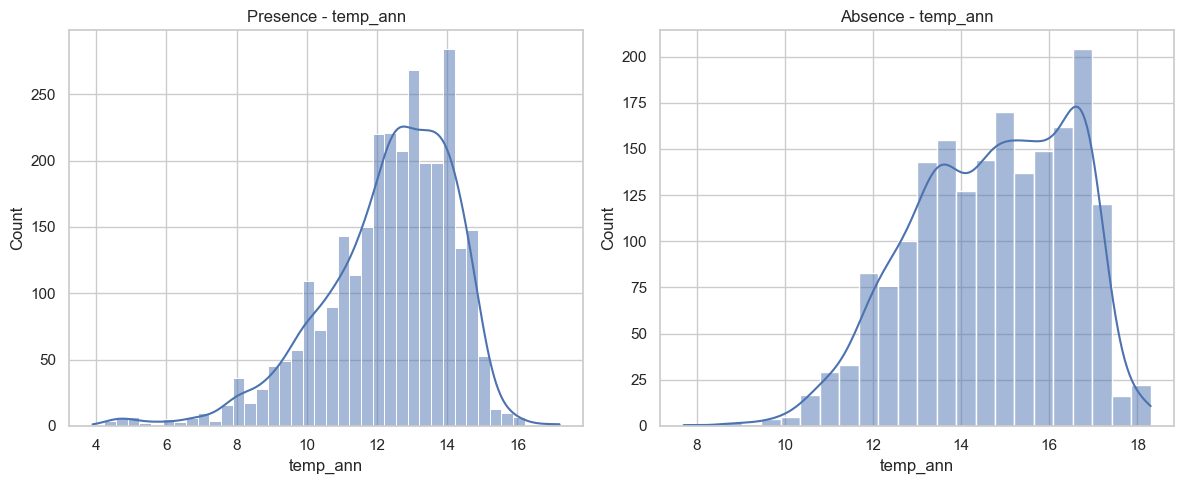

Shapiro Presence: ShapiroResult(statistic=np.float64(0.944234929038207), pvalue=np.float64(5.569994259789673e-32))
Shapiro Absence : ShapiroResult(statistic=np.float64(0.9740450645174886), pvalue=np.float64(4.6440721755782766e-18))
Levene test     : LeveneResult(statistic=np.float64(2.5195499188156947), pvalue=np.float64(0.11250800893689275))


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(presence, kde=True, ax=axes[0])
axes[0].set_title("Presence - temp_ann")

sns.histplot(absence, kde=True, ax=axes[1])
axes[1].set_title("Absence - temp_ann")

plt.tight_layout()
plt.show()

print("Shapiro Presence:", stats.shapiro(presence))
print("Shapiro Absence :", stats.shapiro(absence))
print("Levene test     :", stats.levene(presence, absence))

In [10]:
ttest_raw = stats.ttest_ind(presence, absence, equal_var=False)  # Welch's t-test
ttest_raw

TtestResult(statistic=np.float64(-43.96002093544778), pvalue=np.float64(0.0), df=np.float64(4207.720645195409))

In [11]:
scaler = StandardScaler()
q1["temp_ann_std"] = scaler.fit_transform(q1[["temp_ann"]])

presence_std = q1[q1["trout_presence"] == "Presence"]["temp_ann_std"]
absence_std  = q1[q1["trout_presence"] == "Absence"]["temp_ann_std"]

ttest_std = stats.ttest_ind(presence_std, absence_std, equal_var=False)
ttest_std

TtestResult(statistic=np.float64(-43.96002093544776), pvalue=np.float64(0.0), df=np.float64(4207.720645195409))

In [12]:
mw_raw = stats.mannwhitneyu(presence, absence, alternative="two-sided")
mw_std = stats.mannwhitneyu(presence_std, absence_std, alternative="two-sided")

print("Mann-Whitney raw:", mw_raw)
print("Mann-Whitney std:", mw_std)

Mann-Whitney raw: MannwhitneyuResult(statistic=np.float64(1027812.5), pvalue=np.float64(7.105075261935899e-303))
Mann-Whitney std: MannwhitneyuResult(statistic=np.float64(1027812.5), pvalue=np.float64(7.105075261935899e-303))


In [13]:
summary_q1 = pd.DataFrame({
    "Group": ["Presence", "Absence"],
    "n": [len(presence), len(absence)],
    "Mean_temp_ann": [presence.mean(), absence.mean()],
    "Median_temp_ann": [presence.median(), absence.median()],
    "SD_temp_ann": [presence.std(), absence.std()]
})

summary_q1

,Group,n,Mean_temp_ann,Median_temp_ann,SD_temp_ann
0,Presence,2941,12.336994,12.6,1.880631
1,Absence,1900,14.693684,14.8,1.782060


## Question 1 – Brown Trout presence vs absence and temperature

### Null hypothesis
- **Parametric test (two-sample t-test):**  
  \(H_0: \mu_{Presence} = \mu_{Absence}\)

- **Non-parametric test (Mann–Whitney U):**  
  \(H_0\): the central tendency / distribution of `temp_ann` is the same in presence and absence sites.

### Interpretation
The Welch two-sample t-test was used to compare mean annual temperature between sites with and without *Salmo trutta fario*.

The same analysis was repeated using:
- raw (non-standardized) values
- standardized z-scores

As expected, standardization changed the scale of the variable but **did not materially change the statistical conclusion**, because the relative separation between groups remained the same.

If the p-value is < 0.05, we reject \(H_0\) and conclude that mean annual temperature differs significantly between presence and absence sites.
If the p-value is ≥ 0.05, we fail to reject \(H_0\).

PART E — Exercise 5, Question 2

In [14]:
q2 = data[["Country", "trout_presence"]].dropna().copy()

cont_table = pd.crosstab(q2["Country"], q2["trout_presence"])
cont_table

trout_presence,Absence,Presence
Country,,
France,13,59
Italy,109,76
Portugal,615,252
Spain,1239,2648


In [15]:
chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, index=cont_table.index, columns=cont_table.columns)
expected_df

Chi-square statistic: 496.3723854072799
p-value: 2.9162328651936495e-107
Degrees of freedom: 3


trout_presence,Absence,Presence
Country,,
France,28.391938,43.608062
Italy,72.951507,112.048493
Portugal,341.886250,525.113750
Spain,1532.770305,2354.229695


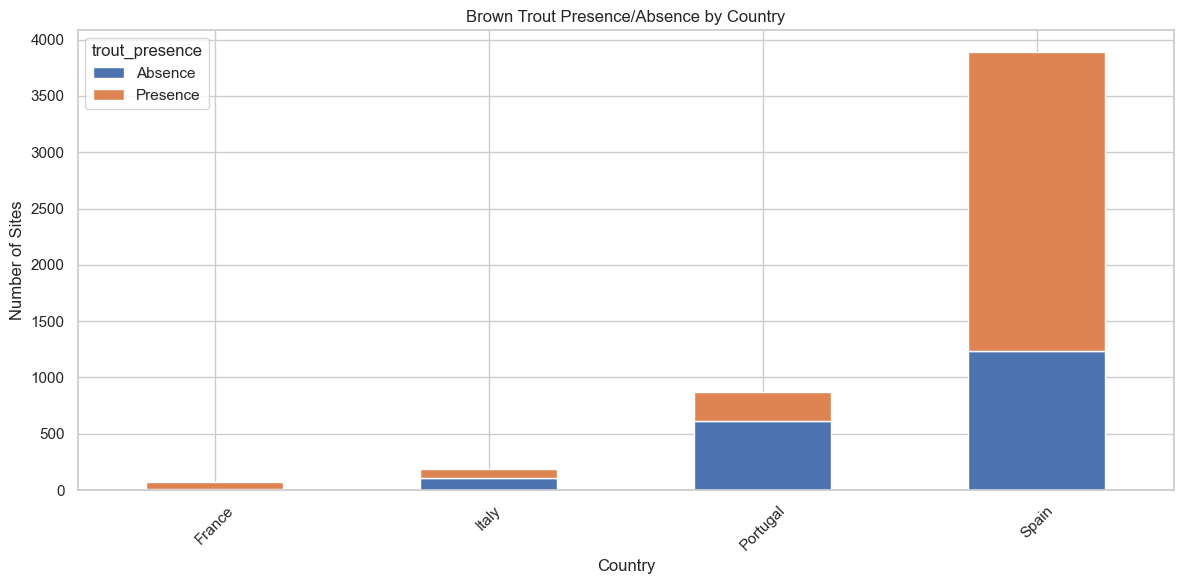

In [16]:
cont_table.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Brown Trout Presence/Absence by Country")
plt.xlabel("Country")
plt.ylabel("Number of Sites")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

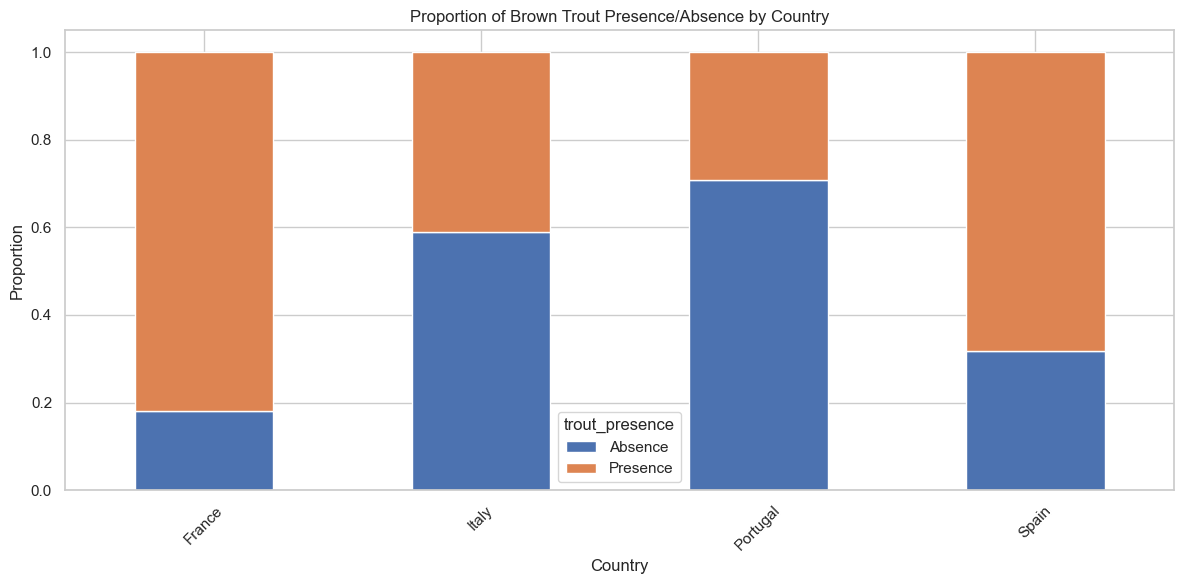

In [17]:
prop_table = cont_table.div(cont_table.sum(axis=1), axis=0)

prop_table.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Proportion of Brown Trout Presence/Absence by Country")
plt.xlabel("Country")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
flow_df = cont_table.reset_index().melt(id_vars="Country", var_name="Presence", value_name="Count")
flow_df = flow_df[flow_df["Count"] > 0]

fig = px.parallel_categories(
    flow_df,
    dimensions=["Country", "Presence"],
    color="Count",
    title="Alluvial-style view: Country vs Brown Trout Presence/Absence"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Question 2 – Brown Trout presence/absence and country

### Null hypothesis
\(H_0\): Brown Trout presence/absence is independent of country.

### Alternative hypothesis
\(H_1\): Brown Trout presence/absence is associated with country.

### Interpretation
A chi-square test of independence was used because both variables are categorical.

If the p-value is < 0.05, we reject \(H_0\) and conclude that Brown Trout occurrence is not independent of country.

If the p-value is ≥ 0.05, we fail to reject \(H_0\), meaning the observed differences among countries may be due to chance.

PART F — Exercise 5, Question 3

In [19]:
q3 = data[["Catchment_name", "Elevation_mean_catch"]].dropna().copy()

top8 = q3["Catchment_name"].value_counts().head(8).index.tolist()
top8

['Ebro',
 'Galiza-Norte',
 'Minho',
 'Tejo',
 'Cantabrica',
 'Douro',
 'Guadia',
 'Catala']

In [20]:
q3_top8 = q3[q3["Catchment_name"].isin(top8)].copy()

q3_top8["Catchment_name"].value_counts()

Catchment_name
Ebro            715
Galiza-Norte    709
Minho           707
Tejo            493
Cantabrica      432
Douro           396
Guadia          307
Catala          217
Name: count, dtype: int64

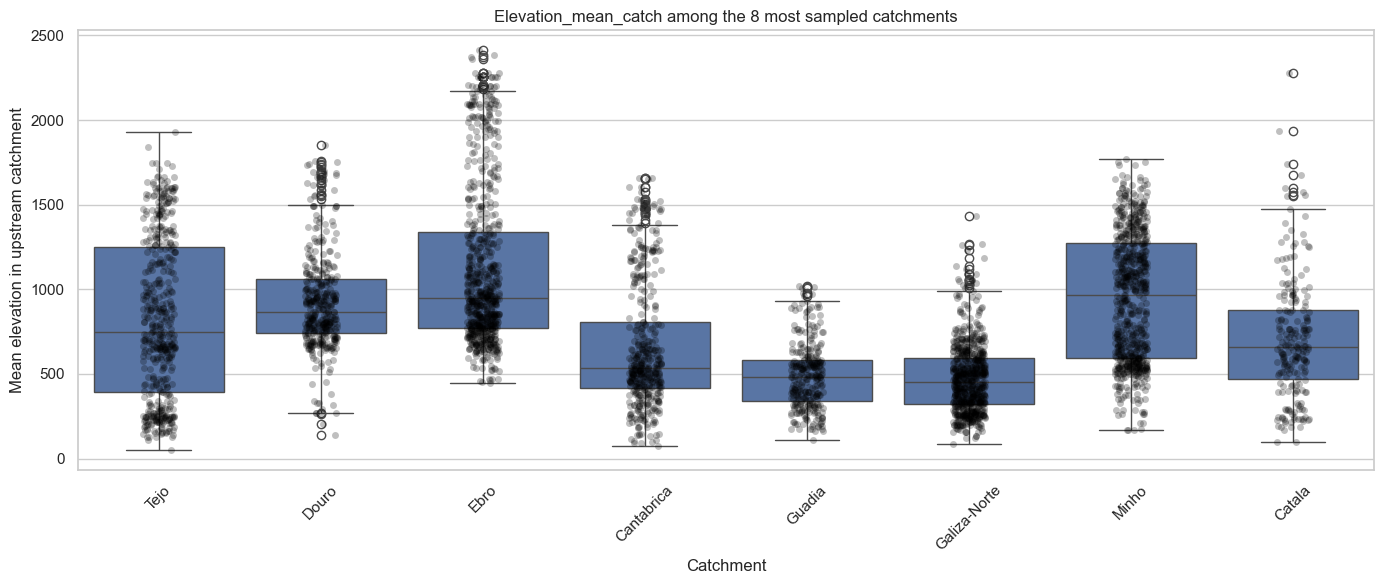

In [21]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=q3_top8, x="Catchment_name", y="Elevation_mean_catch")
sns.stripplot(data=q3_top8, x="Catchment_name", y="Elevation_mean_catch", color="black", alpha=0.25)
plt.title("Elevation_mean_catch among the 8 most sampled catchments")
plt.xlabel("Catchment")
plt.ylabel("Mean elevation in upstream catchment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
model = ols("Elevation_mean_catch ~ C(Catchment_name)", data=q3_top8).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Catchment_name),2.137395e+08,7.0,227.953983,1.369526e-285
Residual,5.315097e+08,3968.0,NaN,NaN


In [23]:
# Residuals normality
residuals = model.resid

print("Shapiro test for residuals:", stats.shapiro(residuals))

# Homogeneity of variance
groups = [
    q3_top8[q3_top8["Catchment_name"] == c]["Elevation_mean_catch"]
    for c in top8
]

print("Levene test:", stats.levene(*groups))

Shapiro test for residuals: ShapiroResult(statistic=np.float64(0.9636761351987154), pvalue=np.float64(1.6489623309157457e-30))
Levene test: LeveneResult(statistic=np.float64(74.60868953197509), pvalue=np.float64(7.092879454417572e-102))


In [24]:
tukey = pairwise_tukeyhsd(
    endog=q3_top8["Elevation_mean_catch"],
    groups=q3_top8["Catchment_name"],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -120.6507   True
      Catala        

In [25]:
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Cantabrica,Catala,50.1883,0.7208,-42.1585,142.5351,False
1,Cantabrica,Douro,268.1584,0.0000,190.9443,345.3726,True
2,Cantabrica,Ebro,467.4299,0.0000,399.7970,535.0628,True
3,Cantabrica,Galiza-Norte,-184.2794,0.0000,-252.0200,-116.5388,True
4,Cantabrica,Guadia,-168.8947,0.0000,-251.7428,-86.0466,True
5,Cantabrica,Minho,290.9895,0.0000,223.2126,358.7663,True
6,Cantabrica,Tejo,168.3227,0.0000,95.1790,241.4664,True
7,Catala,Douro,217.9701,0.0000,124.2303,311.7099,True
8,Catala,Ebro,417.2415,0.0000,331.2221,503.2609,True
9,Catala,Galiza-Norte,-234.4677,0.0000,-320.5718,-148.3636,True


## Question 3 – ANOVA among the 8 most sampled catchments

### Null hypothesis
\(H_0: \mu_1 = \mu_2 = \dots = \mu_8\)

This means that the mean `Elevation_mean_catch` is equal across the eight most sampled catchments.

### Alternative hypothesis
\(H_1\): At least one catchment mean differs from the others.

### Interpretation
A one-way ANOVA was used because:
- the response variable (`Elevation_mean_catch`) is continuous,
- the explanatory variable (`Catchment_name`) is categorical with more than 2 groups,
- and the exercise explicitly states to consider elevation normally distributed.

If the ANOVA p-value is < 0.05, we reject \(H_0\), meaning that not all catchment means are equal.

A Tukey HSD post-hoc test was then used to identify which specific pairs of catchments differ significantly.

PART G — Exercise 5, Question 4

In [26]:
dunn = sp.posthoc_dunn(
    q3_top8,
    val_col="Elevation_mean_catch",
    group_col="Catchment_name",
    p_adjust="bonferroni"
)

dunn

,Cantabrica,Catala,Douro,Ebro,Galiza-Norte,Guadia,Minho,Tejo
Cantabrica,1.000000e+00,7.776285e-01,1.317420e-31,8.151841e-69,1.060456e-13,3.075474e-07,1.737715e-35,9.271577e-09
Catala,7.776285e-01,1.000000e+00,3.884022e-13,1.628849e-29,3.595515e-16,1.742541e-10,6.508382e-13,1.280597e-01
Douro,1.317420e-31,3.884022e-13,1.000000e+00,2.309299e-03,7.926606e-96,3.372119e-60,1.000000e+00,1.473248e-08
Ebro,8.151841e-69,1.628849e-29,2.309299e-03,1.000000e+00,6.749938e-189,1.457688e-106,2.625631e-07,1.605385e-28
Galiza-Norte,1.060456e-13,3.595515e-16,7.926606e-96,6.749938e-189,1.000000e+00,1.000000e+00,7.422061e-122,5.041730e-51
Guadia,3.075474e-07,1.742541e-10,3.372119e-60,1.457688e-106,1.000000e+00,1.000000e+00,9.038610e-68,1.769566e-29
Minho,1.737715e-35,6.508382e-13,1.000000e+00,2.625631e-07,7.422061e-122,9.038610e-68,1.000000e+00,2.084380e-08
Tejo,9.271577e-09,1.280597e-01,1.473248e-08,1.605385e-28,5.041730e-51,1.769566e-29,2.084380e-08,1.000000e+00


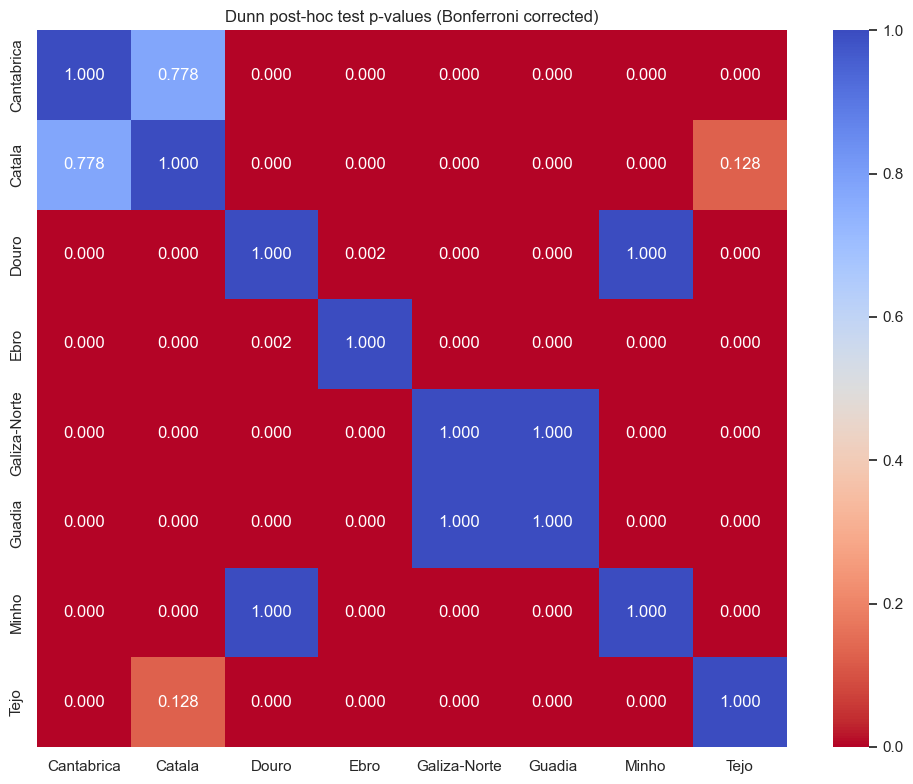

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(dunn, annot=True, cmap="coolwarm_r", fmt=".3f")
plt.title("Dunn post-hoc test p-values (Bonferroni corrected)")
plt.tight_layout()
plt.show()

## Question 4 – Non-parametric equivalent of ANOVA

### Null hypothesis
\(H_0\): The distributions / central tendencies of `Elevation_mean_catch` are equal among the eight catchments.

### Alternative hypothesis
\(H_1\): At least one catchment differs.

### Interpretation
The Kruskal–Wallis test was used as the non-parametric alternative to one-way ANOVA.

This test is useful when:
- normality is questionable,
- outliers are influential,
- or the distribution is not well behaved.

### Comparison with ANOVA
- If both ANOVA and Kruskal–Wallis are significant, the conclusion is robust.
- If ANOVA is significant but Kruskal–Wallis is not, the result may depend on assumptions about normality and variance.
- If Kruskal–Wallis is significant but ANOVA is not, the group differences may be more related to rank/median structure than mean differences.

# Final Conclusions

### Question 1
The difference in `temp_ann` between Brown Trout presence and absence sites was tested using a two-sample comparison.
Both raw and standardized values led to the same overall inference, showing that standardization changed scale but not the substantive result.

### Question 2
The association between Brown Trout presence/absence and country was tested with a chi-square test of independence.
This evaluated whether occurrence patterns vary by country.

### Question 3
Differences in `Elevation_mean_catch` among the 8 most sampled catchments were tested using one-way ANOVA.
Pairwise differences were assessed using Tukey HSD.

### Question 4
The non-parametric equivalent (Kruskal–Wallis) was used to compare with the ANOVA result.
This provided a robustness check for the conclusions.